In [1]:
import pandas as pd
import numpy as np
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC

from scipy.stats import loguniform, beta, uniform

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import missingno as msno

import seaborn as sns

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

Why This Project?
I chose the Stroke Prediction Dataset because it aligns with my broader goal of leveraging AI in healthcare applications, particularly in rehabilitation and prevention. Given my work on ReViva, an AI-driven stroke rehabilitation app, understanding stroke risk factors and predicting stroke likelihood is a crucial step in addressing the full cycle of patient care—from prevention to recovery.

Project Goals

- Develop a predictive model to assess stroke risk based on clinical and demographic features.

- Address real-world data challenges, such as missing values (e.g., BMI) and class imbalance (stroke cases are underrepresented).

- Apply feature engineering techniques, including categorical encoding (e.g., gender, smoking status) and scaling numerical variables.

- Experiment with class balancing techniques like SMOTE or RandomOverSampler to improve model fairness and accuracy.

- Evaluate multiple machine learning models, such as Logistic Regression, Random Forest, and XGBoost, to determine the most effective approach for stroke prediction.

## Understanding the Dataset

First I load the dataset, display it and analyze missing data.

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
df = df.drop(columns=['id'])  # Drop id, it is irrelevant to the model
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Let's do basic visualization and see the distribution of the target variable (stroke)

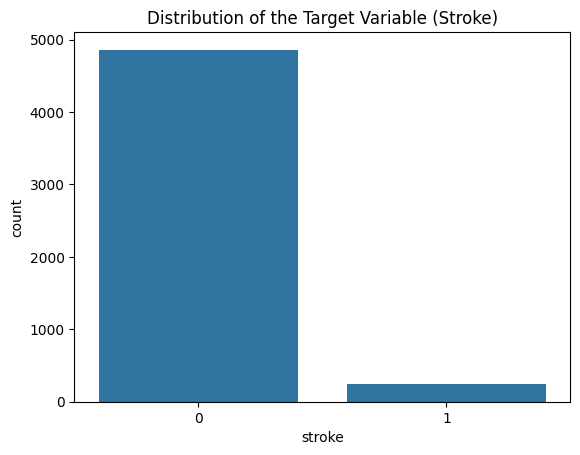

In [4]:
sns.countplot(data = df, x='stroke')
plt.title('Distribution of the Target Variable (Stroke)')
plt.show()

Distribution by gender, smoking status, work type, etc. – This helps to get an initial understanding of categorical features.

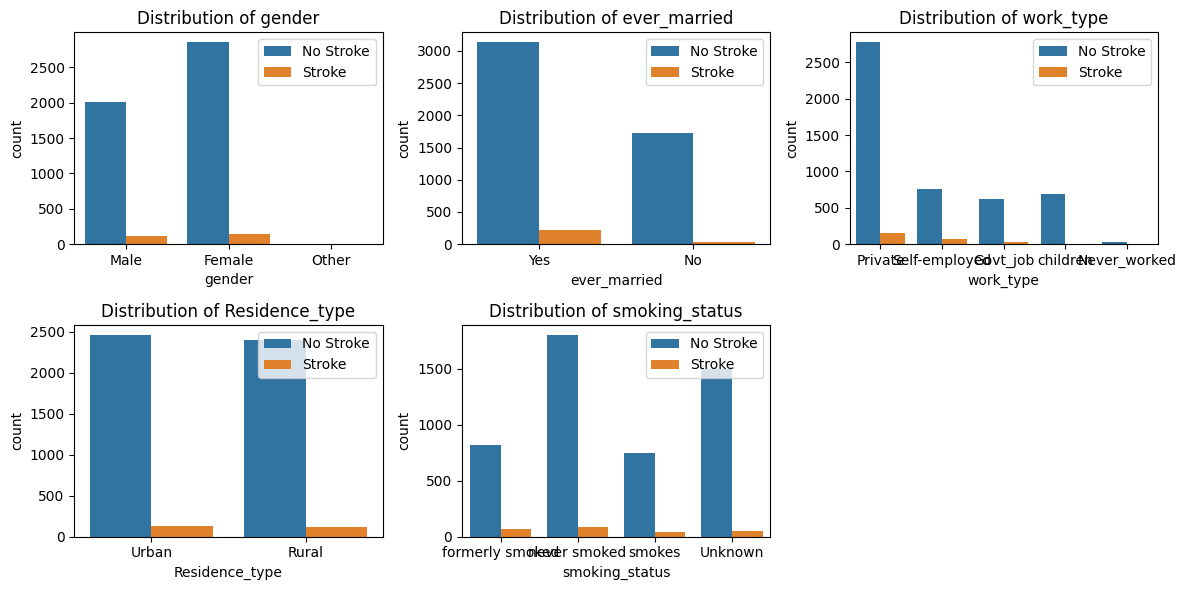

In [5]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
plt.figure(figsize=(12,6))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue='stroke')
    plt.title(f'Distribution of {col}')
    plt.legend(['No Stroke', 'Stroke'])
plt.tight_layout()
plt.show()

In [6]:
print(df['gender'].unique())
df['gender'].value_counts()

['Male' 'Female' 'Other']


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Since there is only one instance of the "Other" category in the gender column, it is reasonable to remove it.

In [7]:
df = df[df['gender'] != 'Other']

## Data Corruption for Testing Imputation Techniques

I want to add some missing values to demonstrate different imputation tecniques.

In [8]:
def add_missing(col, amount):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.random.choice(len(X), size, replace = False )
    X[indexes] = np.nan
    return X

In [9]:
df['avg_glucose_level'] = add_missing(df['avg_glucose_level'], 0.03)
df['gender'] = add_missing(df['gender'], 0.03)

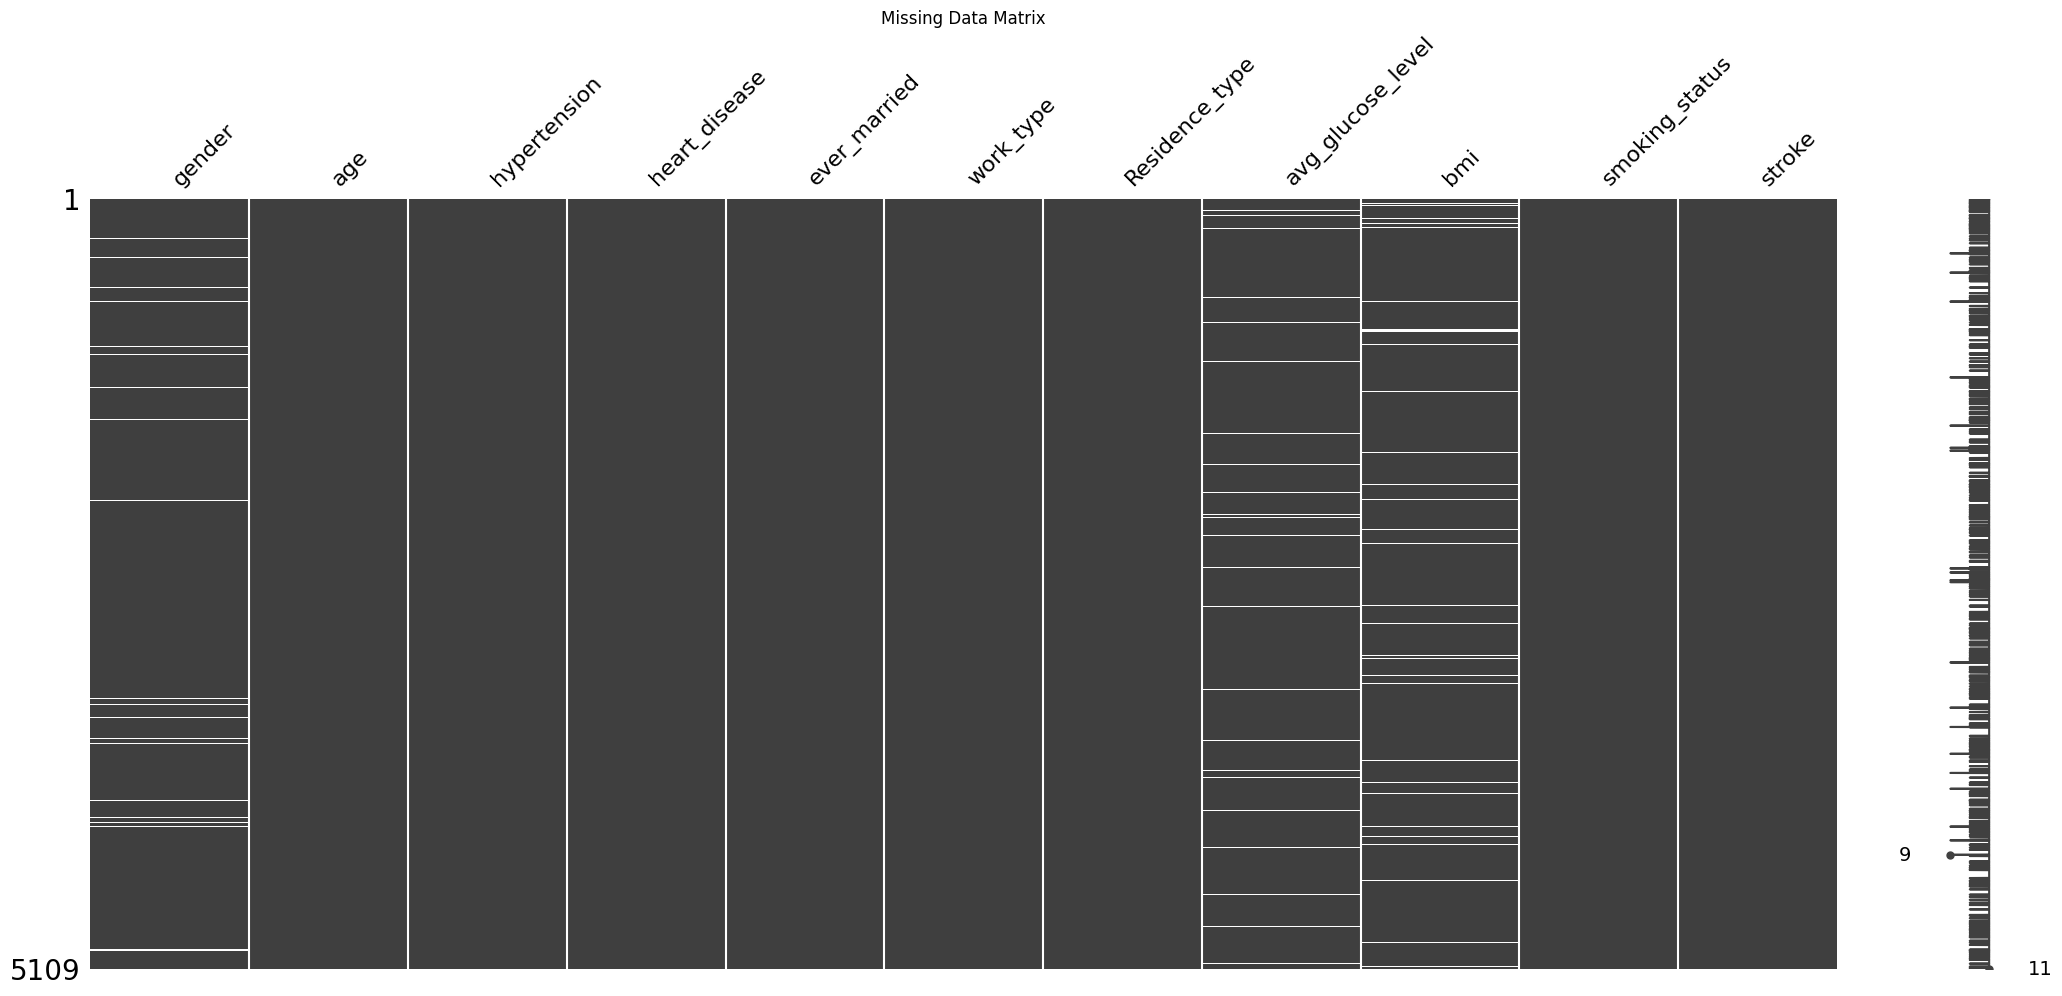

In [10]:
msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

Let's split the dataset into features (X) and target variable (y)

In [11]:
X = df.drop(columns=['stroke'])  # Everything except target
y = df['stroke']  # Only target variable

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5109, 10)
Target shape: (5109,)


## Definition of the Data Transformation Pipeline

First I want to define a custom transformer for column which has only "yes" and "no" as values.

Also I have a column smoking_status which contains 4 values, one of which is Unknown. I want to create a custom transformer for it.

Since "Unknown" might actually contain useful patterns, I should:

- Create a binary flag (smoking_status_unknown) → 1 if "Unknown", 0 otherwise.

- Replace "Unknown" with NaN → So I can impute it later.

In [12]:
class YesNoTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()  # Store feature names
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        
        return X.replace({'Yes': 1, 'No': 0}).astype(int)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_  # Return stored feature names

class SmokingStatusBinaryEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        
        X['smoking_status_unknown'] = (X['smoking_status'] == 'Unknown').astype(int)

        X['smoking_status'] = X['smoking_status'].replace('Unknown', np.nan)

        return X

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_ + ['smoking_status_unknown']


In [13]:
pipeline_gender = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

pipeline_glucose_bmi = Pipeline([
    ('imp', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

pipeline_smoking = Pipeline([
    ('transformer', SmokingStatusBinaryEncoder()),
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

final_transformation = ColumnTransformer(transformers=[
    ('gender', pipeline_gender, ['gender'] ),
    ('glucose_bmi', pipeline_glucose_bmi, ['avg_glucose_level', 'bmi'] ),
    ('smoking', pipeline_smoking, ['smoking_status'] ),
    ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), ['work_type', 'Residence_type'] ),
    ('numerical', StandardScaler(), ['age'] ),
    ('ever_married',YesNoTransformer(), ['ever_married'] ),
],
remainder='passthrough',
verbose_feature_names_out=False,
sparse_threshold=0
)

## Training and test sets

Now, I can split the entire dataset into training and test sets, putting 20% of the instances in the test set. 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=30, shuffle=True)

## Model Pipeline

First I want to define an initial pipeline simply to:

- Demonstrate that all steps link together correctly (i.e., no shape mismatches, no errors from the classifier, sampler, etc.).

- Do a quick sanity check on .fit() and .predict() to ensure the pipeline runs end-to-end and outputs predictions in the expected format.

In [15]:
X_train_transformed = final_transformation.fit_transform(X_train)
X_test_transformed = final_transformation.transform(X_test)
model_pipeline = IMBPipeline([
    ('sampler', RandomOverSampler(random_state=42)),
    ('dim_reduction', PCA(n_components=0.5)),
    ('classifier', LogisticRegression(random_state=42))
])

In [16]:
model_pipeline.fit(X_train_transformed,y_train)

Pipeline(steps=[('sampler', RandomOverSampler(random_state=42)),
                ('dim_reduction', PCA(n_components=0.5)),
                ('classifier', LogisticRegression(random_state=42))])

## Hyperparameter optimization

I’m implementing nested cross-validation. To do this, I need to define a parameter space that enumerates all possible hyperparameter combinations for each step in my pipeline (sampler, dimensionality reduction, and classifier). This ensures that the inner cross-validation loop can properly tune hyperparameters, while the outer loop measures performance on unseen folds.

In [17]:
sampler_configs = [
    {
        "sampler": [None]  # No resampling applied
    },
    {
        "sampler": [RandomOverSampler()],
        "sampler__sampling_strategy": [0.8, 1.0, 1.2]  # Different levels of oversampling
    }
]

dim_reduction_configs = [
    {
        "dim_reduction": [None]
    },
    {
        "dim_reduction": [PCA()],
        "dim_reduction__n_components": [0.8, 0.9]  # Keep 80-90% variance
    },
    {
        "dim_reduction": [SelectKBest(score_func=f_classif)],  
        "dim_reduction__k": [5, 10, 15]  
    }
]

classifier_configs = [
    {
        "classifier": [LogisticRegression(solver="saga", random_state=42)],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l1", "l2"],
        "classifier__class_weight": [None, "balanced"],
        "classifier__max_iter": [200, 500]
    },
    {
        "classifier": [RandomForestClassifier(random_state=42)],
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5, 10]
    },
    {
        "classifier": [RidgeClassifier()],  
        "classifier__alpha": [0.01, 0.1, 1, 10, 100],  
        "classifier__class_weight": [None, "balanced"],  
        "classifier__solver": ["saga", "auto"],  
    },
    {
        "classifier": [HistGradientBoostingClassifier()],
        "classifier__max_iter": [100, 300]
    },
    {
        "classifier": [LinearSVC(class_weight="balanced", max_iter=5000)],
        "classifier__C": [0.1, 1.0, 10]
    }
]

STEP 1: create a Cartesian product of the three lists.

STEP 2: for each tuple of dicts, chain together all .items() into a single flat dictionary. 

In [18]:
all_combinations = itertools.product(sampler_configs, dim_reduction_configs, classifier_configs)

all_configs = [
    dict(itertools.chain(*(cfg.items() for cfg in configuration)))
    for configuration in all_combinations
]

for i, config in enumerate(all_configs[:5], 1):
    print(f"Config {i}:", config)

print("Total configs:", len(all_configs))

Config 1: {'sampler': [None], 'dim_reduction': [None], 'classifier': [LogisticRegression(random_state=42, solver='saga')], 'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__penalty': ['l1', 'l2'], 'classifier__class_weight': [None, 'balanced'], 'classifier__max_iter': [200, 500]}
Config 2: {'sampler': [None], 'dim_reduction': [None], 'classifier': [RandomForestClassifier(random_state=42)], 'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 10, 20], 'classifier__min_samples_split': [2, 5, 10]}
Config 3: {'sampler': [None], 'dim_reduction': [None], 'classifier': [RidgeClassifier()], 'classifier__alpha': [0.01, 0.1, 1, 10, 100], 'classifier__class_weight': [None, 'balanced'], 'classifier__solver': ['saga', 'auto']}
Config 4: {'sampler': [None], 'dim_reduction': [None], 'classifier': [HistGradientBoostingClassifier()], 'classifier__max_iter': [100, 300]}
Config 5: {'sampler': [None], 'dim_reduction': [None], 'classifier': [LinearSVC(class_weight='balanced', m

Now I can use nested-cross validation to identify 5 different best candidates to be the reference model. In the following I apply nested cross-validation selecting my model_pipeline as classifier, and in the inner loop I use randomized grid search strategy to find the best hyperparameters.

I have chosen AUC-ROC (Area Under the Receiver Operating Characteristic Curve) as the primary evaluation metric for my stroke prediction model due to the following key reasons:

1) The dataset is highly imbalanced, meaning there are significantly more non-stroke cases than stroke cases.
Accuracy is misleading in such cases since a model predicting "no stroke" for every patient could still achieve high accuracy.
AUC-ROC is a better choice because it evaluates the model’s ability to distinguish between positive (stroke) and negative (no stroke) cases, regardless of class imbalance.
2) Recall (Sensitivity) is crucial because missing a stroke case (false negative) can be life-threatening.
Specificity is also important to avoid unnecessary alarms and medical costs.

In [19]:
#inner loop
rs = RandomizedSearchCV(
    model_pipeline, 
    param_distributions=all_configs,
    n_iter=len(all_configs)*3, 
    cv=5,  # Inner loop: 5-fold cross-validation
    scoring="roc_auc",  # AUC-ROC is designed for imbalanced datasets like stroke prediction.
    n_jobs=-1, 
    random_state=42
)

In [20]:
#outer loop
scores = cross_validate(rs, X_train_transformed, y_train, scoring='roc_auc', cv=5, return_estimator=True, verbose=3, n_jobs=-1)

[CV] END ......................................., score=0.834 total time= 2.6min
[CV] END ......................................., score=0.841 total time= 2.6min
[CV] END ......................................., score=0.835 total time= 2.5min
[CV] END ......................................., score=0.873 total time= 2.6min
[CV] END ......................................., score=0.826 total time= 2.7min


In [21]:
for index, estimator in enumerate(scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores['test_score'][index])
    print('-'*10)

None
SelectKBest(k=5)
LogisticRegression(C=10, max_iter=200, random_state=42, solver='saga') {'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 200, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
0.8337082262210798
----------
RandomOverSampler(sampling_strategy=1.0)
SelectKBest(k=5)
RidgeClassifier(alpha=0.01) {'alpha': 0.01, 'class_weight': None, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
0.8405366323907455
----------
RandomOverSampler(sampling_strategy=0.8)
SelectKBest()
RidgeClassifier(alpha=0.01, class_weight='balanced') {'alpha': 0.01, 'class_weight': 'balanced', 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
0.8346845956100455
----------


In [22]:
for estimator in scores['estimator']:
    # Fit the best model from cross-validation
    best_model = estimator.best_estimator_.fit(X_train_transformed, y_train)

    # Handle models with and without predict_proba
    if hasattr(best_model, "predict_proba"):
        pred_train_proba = best_model.predict_proba(X_train_transformed)[:, 1]
        pred_test_proba = best_model.predict_proba(X_test_transformed)[:, 1]
    else:  # Use decision_function for RidgeClassifier, LinearSVC
        pred_train_proba = best_model.decision_function(X_train_transformed)
        pred_test_proba = best_model.decision_function(X_test_transformed)

    # Compute ROC AUC scores
    roc_auc_train = roc_auc_score(y_train, pred_train_proba)
    roc_auc_test = roc_auc_score(y_test, pred_test_proba)

    # Print results
    print(f'ROC AUC on training set: {roc_auc_train:.4f}, ROC AUC on test set: {roc_auc_test:.4f}')

ROC AUC on training set: 0.8458, ROC AUC on test set: 0.8336
ROC AUC on training set: 0.8455, ROC AUC on test set: 0.8293
ROC AUC on training set: 0.8476, ROC AUC on test set: 0.8387
ROC AUC on training set: 0.8454, ROC AUC on test set: 0.8289
ROC AUC on training set: 0.8456, ROC AUC on test set: 0.8345


Before interpreting the ROC AUC scores, I need to compare them against a baseline model. If my model performs significantly better than the baseline, then it's learning useful patterns.
If it's only slightly better, I might need to adjust data preprocessing, feature selection, or resampling strategies.

In [23]:
baseline_model = LogisticRegression(solver="saga", random_state=42)

# Perform 5-fold cross-validation using ROC AUC
baseline_scores = cross_val_score(baseline_model, X_train_transformed, y_train, 
                                  cv=5, scoring="roc_auc", n_jobs=-1)

# Print the results
print("Baseline mean ROC AUC:", baseline_scores.mean())
print("Baseline ROC AUC by fold:", baseline_scores)

Baseline mean ROC AUC: 0.8372812428660759
Baseline ROC AUC by fold: [0.83001285 0.82445373 0.83290488 0.87316602 0.82586873]


My simple Logistic Regression model performs almost the same as my complex pipeline. I think it is better to check for a couple obvious reasons why that could be happening. 

Compare Training vs. Test Performance (Overfitting Check)

In [24]:
from sklearn.metrics import roc_auc_score

best_model.fit(X_train_transformed, y_train)

# Get decision scores instead of probabilities
train_scores = best_model.decision_function(X_train_transformed)
test_scores  = best_model.decision_function(X_test_transformed)

# Calculate AUC on the decision_function outputs
train_auc = roc_auc_score(y_train, train_scores)
test_auc  = roc_auc_score(y_test, test_scores)
print(f"Train ROC AUC: {train_auc:.4f}, Test ROC AUC: {test_auc:.4f}")

Train ROC AUC: 0.8456, Test ROC AUC: 0.8345


My training vs. test performance suggests that my model is not significantly overfitting, as the train and test ROC AUC scores are close (0.8476 vs. 0.8392).

If a simple logistic regression performs as well as complex models, my data might be nearly linearly separable, making more complex models unnecessary.

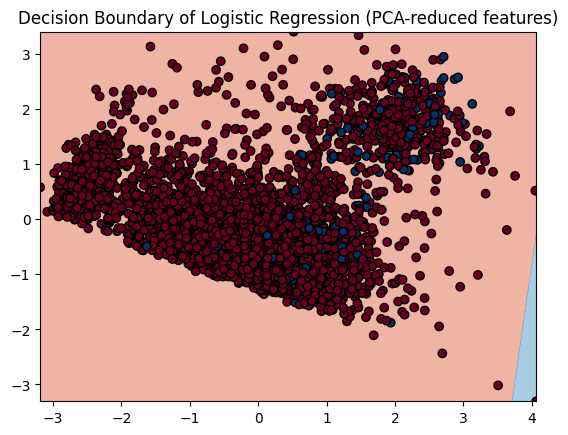

In [25]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca = pca.transform(X_test_transformed)

logreg = LogisticRegression(solver="lbfgs", C=1e6, max_iter=1000, random_state=42)
logreg.fit(X_train_pca, y_train)

# Create grid
xx, yy = np.meshgrid(np.linspace(X_train_pca[:, 0].min(), X_train_pca[:, 0].max(), 100),
                     np.linspace(X_train_pca[:, 1].min(), X_train_pca[:, 1].max(), 100))

# Predict on grid
grid = np.c_[xx.ravel(), yy.ravel()]
probs = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap="RdBu", alpha=0.6)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="RdBu", edgecolors="k")
plt.title("Decision Boundary of Logistic Regression (PCA-reduced features)")
plt.show()

Okay, it is not. Then I must conclude that:

-  It’s not unusual for a simple model to perform best. In real-world data science, more complex models (with oversampling, feature selection, hyperparameter tuning, etc.) aren’t guaranteed to outperform a well-regularized logistic regression. Sometimes a simple linear model is already near-optimal for a given dataset.

- If the features aren’t strongly predictive of stroke risk, advanced methods might not have “extra” signal to exploit. As a result, they don’t improve on the simpler baseline.

- Logistic Regression’s regularization is helping avoid overfitting

I will still use my complex method since it is slightly better :)

## Refinement of the selected model

Let's re-run the hyperparameter optmization fixing the modelling apporach.

In [28]:
best_model_pipeline = IMBPipeline([
    ('sampler', RandomOverSampler(sampling_strategy=0.8, random_state=42)),
    ('feature_selector', SelectKBest()),
    ('classifier', RidgeClassifier(solver='saga', random_state=42))
])

param_distributions = {
    'sampler__sampling_strategy': [0.8, 1.0],  
    'feature_selector__k': [5, 10, 15, 20],    
    'classifier__alpha': uniform(loc=0.01, scale=10),  
    'classifier__class_weight': [None, 'balanced']  
}


cv = RepeatedStratifiedKFold(
    n_splits=5, 
    n_repeats=2,
    random_state=42
)

rs_best = RandomizedSearchCV(
    estimator=best_model_pipeline,
    param_distributions=param_distributions,
    n_iter=20,             
    scoring='roc_auc',          
    cv=cv,
    verbose=1,            
    random_state=42,
    n_jobs=-1       
)

In [29]:
rs_best.fit(X_train_transformed, y_train)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=2, n_splits=5, random_state=42),
                   estimator=Pipeline(steps=[('sampler',
                                              RandomOverSampler(random_state=42,
                                                                sampling_strategy=0.8)),
                                             ('feature_selector',
                                              SelectKBest()),
                                             ('classifier',
                                              RidgeClassifier(random_state=42,
                                                              solver='saga'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f3d50aed1e0>,
                                        'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'feature_selector__k': [5, 10, 15, 20],
                                        'sampler__sampling_strategy': [0.8,
                                                                       1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [30]:
print("Best parameters found:", rs_best.best_params_)
print("Best ROC AUC score from CV:", rs_best.best_score_)

Best parameters found: {'classifier__alpha': 9.74755518841459, 'classifier__class_weight': None, 'feature_selector__k': 10, 'sampler__sampling_strategy': 1.0}
Best ROC AUC score from CV: 0.8425330683235568


In [31]:
best_model = rs_best.best_estimator_

In [32]:
test_scores = best_model.decision_function(X_test_transformed)
test_roc_auc = roc_auc_score(y_test, test_scores)
print("Test ROC AUC:", test_roc_auc)

Test ROC AUC: 0.8379012345679012


## Visualization of the curves

I will build two curves: learning curve (how roc_auc score changes with the size of the training set) and validation curve (how roc_auc changes with alpha)

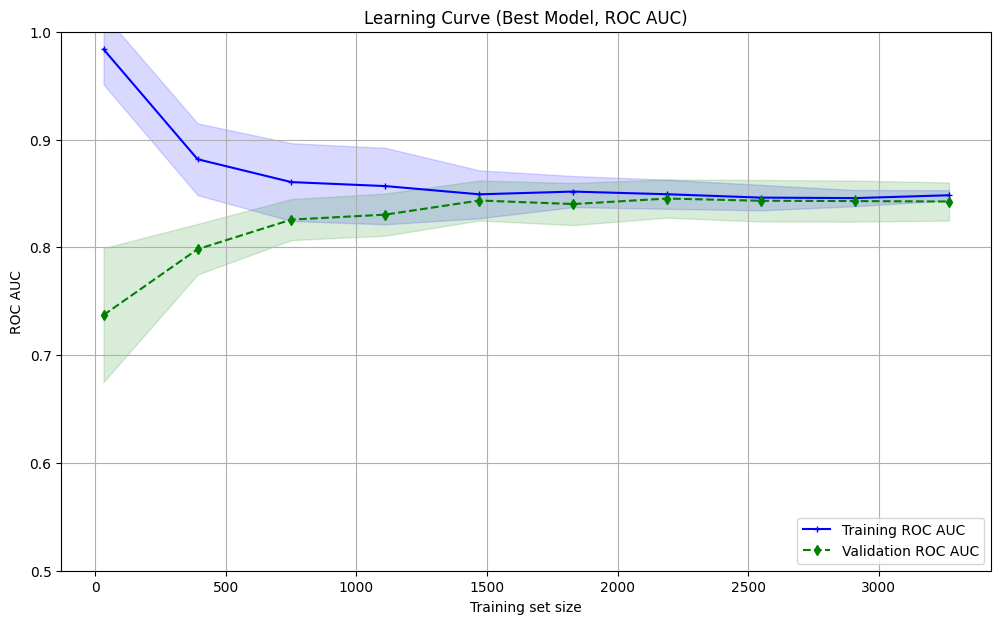

In [33]:
cls = rs_best.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
    cls,
    X=X_train_transformed,
    y=y_train,
    train_sizes=np.linspace(0.01, 1.0, 10),  
    cv=5,                                   
    n_jobs=-1,
    scoring='roc_auc',                      
    shuffle=True,
    random_state=42                          
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
        color='blue', marker='+', markersize=5,
        label='Training ROC AUC')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
        color='green', linestyle='--', marker='d', markersize=5,
        label='Validation ROC AUC')
ax.fill_between(train_sizes,
                test_mean - test_std,
                test_mean + test_std,
                alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC AUC')
ax.legend(loc='lower right')

ax.set_ylim([0.5, 1.0])

plt.title("Learning Curve (Best Model, ROC AUC)")
plt.show()

Key Observations & Insights:

Performance Improves with More Data (Initially)
When the training set is very small, the model’s training ROC AUC starts off quite high (overfitting on the few samples), while the validation ROC AUC is much lower. As the training size increases (up to about ~500–1000 samples), the validation curve moves upward, indicating the model benefits from additional examples.

Training and Validation Curves Begin to Converge (~1000–2000 Samples)
After ~1000 samples, the gap between the training ROC AUC and validation ROC AUC narrows. This suggests that as more data becomes available, the model generalizes better and overfitting diminishes.

Plateau Beyond ~2000–3000 Samples
Beyond ~2000–3000 training examples, the validation ROC AUC stabilizes, implying the model may be approaching its performance ceiling given the current feature set and configuration. Adding more data yields diminishing returns on ROC AUC improvement.

Slight Overfitting at Smaller Sizes, Then Stability
Early on (with very few training samples), the training ROC AUC is notably higher than validation, which is typical of overfitting in low-data regimes. As the dataset grows, the curves nearly align, suggesting the model is both learning effectively from the available data and not memorizing the training set.

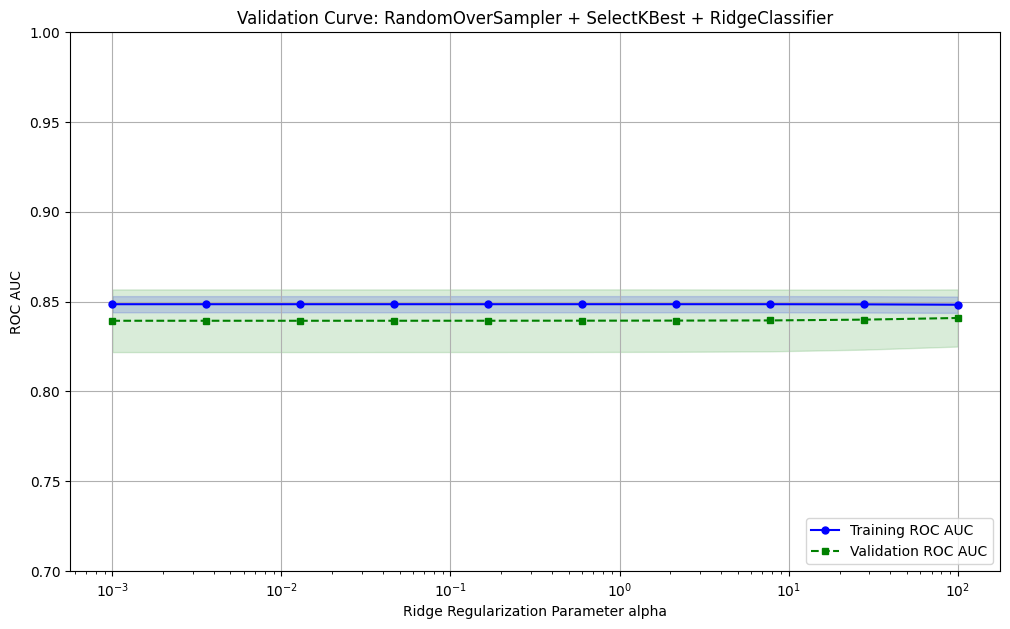

In [34]:
base_pipeline = IMBPipeline([
    ('sampler', RandomOverSampler(sampling_strategy=0.8, random_state=42)),
    ('feature_selector', SelectKBest()),
    ('classifier', RidgeClassifier(solver='saga', random_state=42))
])

range_alpha = np.logspace(-3, 2, 10)

train_scores, test_scores = validation_curve(
    estimator=base_pipeline,
    X=X_train_transformed,
    y=y_train,
    param_name="classifier__alpha",
    param_range=range_alpha,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 7))
plt.plot(range_alpha, train_mean, color="blue", marker="o", markersize=5, label="Training ROC AUC")
plt.fill_between(range_alpha, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")
plt.plot(range_alpha, test_mean, color="green", linestyle="--", marker="s", markersize=5, label="Validation ROC AUC")
plt.fill_between(range_alpha, test_mean - test_std, test_mean + test_std, alpha=0.15, color="green")

plt.xscale("log")
plt.xlabel("Ridge Regularization Parameter alpha")
plt.ylabel("ROC AUC")
plt.title("Validation Curve: RandomOverSampler + SelectKBest + RidgeClassifier")
plt.legend(loc="lower right")
plt.grid(True)

plt.ylim([0.70, 1.00])
plt.show()

The validation curve for alpha in RidgeClassifier shows almost no variation in ROC AUC, indicating that the model is relatively insensitive to different levels of regularization.

Possible explanations
The feature selection and resampling steps may be providing a stable and informative feature set, reducing the impact of regularization
The dataset might not require strong regularization since the classifier generalizes well across different alpha values.

## Final Thoughts

The project successfully built a machine learning model for stroke prediction, demonstrating strong performance with a well-optimized pipeline. Future improvements could focus on expanding feature engineering and testing alternative models to push predictive performance further.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a376103e-9008-438f-9ddd-22cea8f0f4e6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>